In [ ]:
import numpy as np
import pandas as pd
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models

# -------------------------
# CONFIG
# -------------------------
TIME_COL = "TIME"
# Number of samples are inside each window
T = 64
# How far the window moves at each step
STRIDE = 2
BATCH = 128
EPOCHS = 30
SEED = 42
rng = np.random.default_rng(SEED)

# 0 means non-leak, 1 means leak
runs = [
    ("normal.csv", 0, "NORM"),   # non-leak
    ("tt.csv", 0, "TT"),         # non-leak accident
    ("sp.csv", 0, "SP"),         # non-leak accident
    ("atws.csv", 0, "ATWS"),     # non-leak accident
    ("loca_1.csv", 1, "LOCA1"),  # leak
    ("loca_2.csv", 1, "LOCA2"),
    ("loca_3.csv", 1, "LOCA3"),
    ("SGATR_1.csv", 1, "SGATR1"), # leak
    ("SGATR_2.csv", 1, "SGATR2"),
    ("SGATR_3.csv", 1, "SGATR3"),
]

# ----------------------------------------------------------------------------------------#
#                                  1. DATA PRE-PROCESSING                                 #
# ----------------------------------------------------------------------------------------#

# -------------------------
# Helpers
# -------------------------
# Load csv into dataframe
def load_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    return df

# Keep only numeric columns except TIME
def get_numeric_feature_cols(df: pd.DataFrame) -> list[str]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cols = [c for c in numeric_cols if c != TIME_COL]
    return cols

# Turn time-series data into a supervised learning dataset
def make_windows(x: np.ndarray, T: int, stride: int) -> np.ndarray:
    N, F = x.shape
    if N < T:
        return np.empty((0, T, F), dtype=np.float32)
    idxs = range(0, N - T + 1, stride)
    return np.stack([x[i:i+T] for i in idxs], axis=0).astype(np.float32)

# -------------------------
# Load all runs + choose common feature columns (intersection)
# -------------------------
dfs = []
all_feature_sets = []

for path, y, name in runs:
    df = load_df(path)
    cols = get_numeric_feature_cols(df)
    if len(cols) == 0:
        raise ValueError(f"No numeric sensor columns found (excluding {TIME_COL}) in {path}.")
    dfs.append((df, path, y, name))
    all_feature_sets.append(set(cols))

# Use intersection so every run has same feature columns
feature_cols_ref = sorted(list(set.intersection(*all_feature_sets)))
if len(feature_cols_ref) == 0:
    raise ValueError("No common numeric feature columns across runs. Check CSV headers.")

print("Using features (common across runs):", feature_cols_ref)

# -------------------------
# Build windows for each run
# -------------------------
run_windows = []  # list of (Xw, yw, run_name)
for df, path, y, name in dfs:
    x = df[feature_cols_ref].astype(np.float32).values  # (N,F)
    Xw = make_windows(x, T=T, stride=STRIDE)            # (W,T,F)
    if Xw.shape[0] == 0:
        raise ValueError(f"Not enough samples in {path} to form one window of length T={T}.")
    yw = np.full((Xw.shape[0],), y, dtype=np.int32)
    run_windows.append((Xw, yw, name))

# -------------------------
# Prototype split (time-based within each run)
# -------------------------
def split_windows_timewise(Xw, yw, train_frac=0.7, val_frac=0.15):
    W = Xw.shape[0]
    i1 = int(train_frac * W)
    i2 = int((train_frac + val_frac) * W)
    X_train, y_train = Xw[:i1], yw[:i1]
    X_val,   y_val   = Xw[i1:i2], yw[i1:i2]
    X_test,  y_test  = Xw[i2:], yw[i2:]
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []
X_test_list, y_test_list = [], []

for Xw, yw, name in run_windows:
    Xt, yt, Xv, yv, Xte, yte = split_windows_timewise(Xw, yw)
    X_train_list.append(Xt); y_train_list.append(yt)
    X_val_list.append(Xv);   y_val_list.append(yv)
    X_test_list.append(Xte); y_test_list.append(yte)

X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
X_val   = np.concatenate(X_val_list, axis=0)
y_val   = np.concatenate(y_val_list, axis=0)
X_test  = np.concatenate(X_test_list, axis=0)
y_test  = np.concatenate(y_test_list, axis=0)

print("Shapes:")
print("train:", X_train.shape, y_train.shape, "class counts:", np.bincount(y_train))
print("val  :", X_val.shape,   y_val.shape,   "class counts:", np.bincount(y_val) if len(y_val) else "[]")
print("test :", X_test.shape,  y_test.shape,  "class counts:", np.bincount(y_test))

# -------------------------
# Scale
# -------------------------
Wtr, Ttr, Ftr = X_train.shape
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, Ftr))

def scale_windows(Xw):
    W, Tt, F = Xw.shape
    Xflat = Xw.reshape(-1, F)
    Xflat = scaler.transform(Xflat)
    return Xflat.reshape(W, Tt, F).astype(np.float32)

X_train_s = scale_windows(X_train)
X_val_s   = scale_windows(X_val) if len(X_val) else X_val
X_test_s  = scale_windows(X_test)

# -------------------------
# Class weights
# -------------------------
classes_present = np.unique(y_train)
if len(classes_present) == 2:
    cw = compute_class_weight(class_weight="balanced", classes=np.array([0,1]), y=y_train)
    class_weight = {0: cw[0], 1: cw[1]}
else:
    # Shouldn't happen with the timewise split, but just in case
    class_weight = None
print("class_weight:", class_weight)

# ----------------------------------------------------------------------------------------#
#                                      2. MODELLING                                       #
# ----------------------------------------------------------------------------------------#

# -------------------------
# Build the model
# -------------------------
model = models.Sequential([
    layers.Input(shape=(T, len(feature_cols_ref))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

# -------------------------
# Compile the model
# -------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),             # how well it separates classes
        tf.keras.metrics.Precision(name="precision"), # how many predicted leaks are correct
        tf.keras.metrics.Recall(name="recall"),       # how many actual leaks are caught
        tf.keras.metrics.BinaryAccuracy(name="acc"),
    ]
)

# ---------------------------------------------
# Stop early if it doesn't improve for 5 epochs
# ---------------------------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True)
]

# -------------------------
# Train the model
# -------------------------
history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

# ----------------------------------------------------------------------------------------#
#                                  3. EVALUATE                                            #
# ----------------------------------------------------------------------------------------#
# Gets preformance metrics of the trained model on test data
proba = model.predict(X_test_s, batch_size=BATCH, verbose=0).reshape(-1)
y_pred = (proba >= 0.5).astype(np.int32)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["non-leak", "leak"]))

# ----------------------------------------------------------------------------------------#
#                                      4. SAVE                                            #
# ----------------------------------------------------------------------------------------#
model.save("lstm_leak_classifier.keras")
# Saves the trained model
joblib.dump(scaler, "scaler.pkl")
# Saves the scaler
joblib.dump({
    "feature_cols": feature_cols_ref,
    "time_steps": T,
    "stride": STRIDE
}, "config.pkl")

Using features (common across runs): ['CNH2', 'DNBR', 'DTHY', 'DWB', 'EBK', 'FRCL', 'FRZR', 'HLW', 'HTR', 'HUP', 'LSGA', 'LSGB', 'LVCR', 'LVPZ', 'LWRB', 'MBK', 'MCRT', 'MDBR', 'MGAS', 'MH2', 'NSGA', 'NSGB', 'P', 'PPM', 'PRB', 'PRBA', 'PSGA', 'PSGB', 'PWNT', 'PWR', 'QFCL', 'QMGA', 'QMGB', 'QMWT', 'QRHR', 'RBLK', 'RC131', 'RC87', 'RH', 'RHBR', 'RHFL', 'RHMT', 'RHRD', 'RM1', 'RM2', 'RM3', 'RM4', 'RRCA', 'RRCB', 'RRCO', 'SCMA', 'SCMB', 'SGLK', 'STRB', 'STSG', 'STTB', 'TAVG', 'TBLD', 'TCA', 'TCB', 'TCRT', 'TDBR', 'TF', 'TFPK', 'TFSB', 'THA', 'THB', 'TKLV', 'TPCT', 'TRB', 'TSAT', 'TSLP', 'VOID', 'VOL', 'WBK', 'WCFT', 'WCHG', 'WCSP', 'WECS', 'WFLB', 'WFWA', 'WFWB', 'WHPI', 'WLD', 'WLPI', 'WLR', 'WRCA', 'WRCB', 'WRLA', 'WRLB', 'WSPY', 'WSTA', 'WSTB', 'WTRA', 'WTRB', 'WUP']
Shapes:
train: (1574, 64, 96) (1574,) class counts: [653 921]
val  : (339, 64, 96) (339,) class counts: [140 199]
test : (341, 64, 96) (341,) class counts: [141 200]
class_weight: {0: np.float64(1.2052067381316998), 1: np.fl

['config.pkl']

Windows: (235, 64, 96)


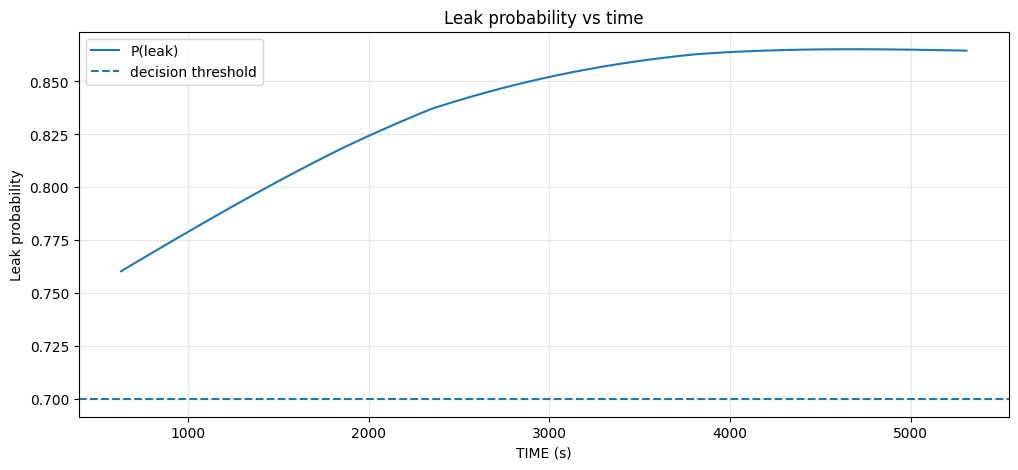

Leak score: 0.83738667


In [ ]:
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------
# Load artifacts
# -----------------
model = tf.keras.models.load_model("lstm_leak_classifier.keras")
scaler = joblib.load("scaler.pkl")
config = joblib.load("config.pkl")

feature_cols = config["feature_cols"]
T = config["time_steps"]
STRIDE = config["stride"]

TIME_COL = "TIME"

def make_windows(x, T, stride):
    N, F = x.shape
    if N < T:
        return np.empty((0, T, F), dtype=np.float32)
    idxs = range(0, N - T + 1, stride)
    return np.stack([x[i:i+T] for i in idxs], axis=0)

def run_leak_detection(csv_path):
    # -----------------
    # Load data
    # -----------------
    df = pd.read_csv(csv_path)

    # Ensure required columns exist
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # -----------------
    # Extract + scale
    # -----------------
    x = df[feature_cols].values.astype(np.float32)
    x_scaled = scaler.transform(x)

    # -----------------
    # Windowing
    # -----------------
    Xw = make_windows(x_scaled, T, STRIDE)
    print("Windows:", Xw.shape)

    if len(Xw) == 0:
        print("Not enough data for one window")
        return None

    # -----------------
    # Predict
    # -----------------
    proba = model.predict(Xw, verbose=0).reshape(-1)

    # Align time with window end
    times = df[TIME_COL].values[T-1::STRIDE]

    return times, proba

times, proba = run_leak_detection("SGATR_5.csv")

plt.figure(figsize=(12,5))
plt.plot(times, proba, label="P(leak)")
plt.axhline(0.7, linestyle="--", label="decision threshold")
plt.xlabel("TIME (s)")
plt.ylabel("Leak probability")
plt.title("Leak probability vs time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

leak_score = np.mean(proba)
print("Leak score:", leak_score)